In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 1.26.4
pandas 2.2.3
sklearn 1.6.0
torch 2.7.1+cpu
cpu


# 数据预处理

In [2]:
from pathlib import Path

DATA_DIR = Path("D:/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv" #测试集模板csv文件
train_folder = DATA_DIR / "train/train"
test_folder = DATA_DIR / "test/test"


#所有的类别
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]
# INSERT_YOUR_CODE
import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    """
    读取labels_csv_path（trainLabels.csv），为每张图片拼接完整路径，并返回[(img_path, label), ...]的列表
    """
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']  # 假设csv第一列是id（去掉.jpg后缀的文件名）
        label = row['label']
        img_path = images_folder / f"{img_name}.png"  # cifar10可能是png，也可能是jpg，请确保格式一致
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

# 示例调用方法
train_items = load_image_paths_and_labels(train_lables_file, train_folder)
# test_items = load_image_paths_and_labels(test_csv_file, test_folder)

import pprint
pprint.pprint(train_items[:5])



[('D:\\cifar-10\\train\\train\\1.png', 'frog'),
 ('D:\\cifar-10\\train\\train\\2.png', 'truck'),
 ('D:\\cifar-10\\train\\train\\3.png', 'truck'),
 ('D:\\cifar-10\\train\\train\\4.png', 'deer'),
 ('D:\\cifar-10\\train\\train\\5.png', 'automobile')]


In [3]:
# INSERT_YOUR_CODE
import pandas as pd

# 将train_items分为45000条用于训练，5000条用于验证
train_items_ = train_items[:45000]
valid_items_ = train_items[45000:]

# 转为DataFrame
train_df = pd.DataFrame(train_items_, columns=["img_path", "label"])
valid_df = pd.DataFrame(valid_items_, columns=["img_path", "label"])
# test_df = pd.DataFrame(test_items, columns=["img_path", "label"])


In [4]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)} # 类别映射为idx
    idx_to_label = {idx: label for idx, label in enumerate(class_names)} # idx映射为类别,为了test使用
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None) # 获取对应模式的df，不同字符串对应不同模式
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        # assert self.df, "df is None"
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index] # 获取图片路径和标签
        img = Image.open(img_path).convert('RGB')
        # # img 转换为 channel first
        # img = img.transpose((2, 0, 1))
        # transform
        img = self.transform(img) # 数据增强
        # label 转换为 idx
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0] # 返回df的行数,样本数

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), #缩放
        # random rotation 40
        transforms.RandomRotation(40), #随机旋转
        # horizaontal flip
        transforms.RandomHorizontalFlip(),  #随机水平翻转
        transforms.ToTensor(), #转换为tensor
        transforms.Normalize(mean, std) #标准化
    ]) #数据增强

transforms_eval = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
# ToTensor还将图像的维度从[height, width, channels]转换为[channels, height, width]。
train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [5]:

# 对train_ds计算均值和标准差
# from torch.utils.data import DataLoader
# import torch
#
# loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
#
# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0
#
# for images, _ in loader:  # images: [B, 3, H, W]
#     batch_pixels = images.shape[0] * images.shape[2] * images.shape[3]
#     mean += images.sum([0, 2, 3])
#     std += (images ** 2).sum([0, 2, 3])
#     n_pixels += batch_pixels
#
# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)
#
# print("train_ds按通道均值:", mean)
# print("train_ds按通道标准差:", std)



In [6]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
)

test_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
for batch_images, batch_labels in train_loader:
    print(f"批次图像张量形状: {batch_images.shape}")
    print(f"批次标签张量形状: {batch_labels.shape}")
    print(batch_labels)
    break

训练集DataLoader批次数: 1407
测试集DataLoader批次数: 157
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 32, 32])
批次标签张量形状: torch.Size([32])
tensor([8, 2, 0, 0, 3, 7, 4, 9, 4, 7, 6, 0, 9, 4, 7, 4, 1, 2, 0, 6, 5, 8, 8, 7,
        4, 1, 7, 0, 6, 9, 3, 6])


# 搭建模型

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 定义InceptionBlock，模拟GoogleNet中的Inception结构
class InceptionBlock(nn.Module):
    def __init__(
        self, 
        in_channels,   # 输入特征图的通道数
        n1x1,          # 1x1卷积分支输出通道数
        n3x3red,       # 3x3卷积分支，先做1x1降维，降维后输出通道数
        n3x3,          # 3x3卷积分支，3x3卷积后输出通道数
        n5x5red,       # 5x5卷积分支，先做1x1降维，降维后输出通道数
        n5x5,          # 5x5卷积分支，5x5卷积后输出通道数
        pool_proj      # 池化+1x1卷积分支中，1x1卷积输出通道数
    ):
        super(InceptionBlock, self).__init__()
        # 第一分支：单独的1x1卷积，用于提取简单特征，增强非线性
        self.branch1 = nn.Conv2d(in_channels, n1x1, kernel_size=1)
        
        # 第二分支：1x1卷积降维后接3x3卷积
        self.branch2_1 = nn.Conv2d(in_channels, n3x3red, kernel_size=1)
        self.branch2_2 = nn.Conv2d(n3x3red, n3x3, kernel_size=3, padding=1)  # padding=1 保证尺寸不变
        
        # 第三分支：1x1卷积降维后接5x5卷积
        self.branch3_1 = nn.Conv2d(in_channels, n5x5red, kernel_size=1)
        self.branch3_2 = nn.Conv2d(n5x5red, n5x5, kernel_size=5, padding=2)  # padding=2 保证尺寸不变
        
        # 第四分支：3x3最大池化后，再接1x1卷积(用于压缩通道数)
        self.branch4_pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1) # 池化不会改变尺寸
        self.branch4_conv = nn.Conv2d(in_channels, pool_proj, kernel_size=1)

    def forward(self, x):
        # 第一分支的前向传播：1x1卷积 + ReLU
        branch1 = F.relu(self.branch1(x), inplace=True)

        # 第二分支：1x1卷积 + ReLU -> 3x3卷积 + ReLU
        branch2 = F.relu(self.branch2_1(x), inplace=True)
        branch2 = F.relu(self.branch2_2(branch2), inplace=True)
        
        # 第三分支：1x1卷积 + ReLU -> 5x5卷积 + ReLU
        branch3 = F.relu(self.branch3_1(x), inplace=True)
        branch3 = F.relu(self.branch3_2(branch3), inplace=True)
        
        # 第四分支：3x3最大池化 -> 1x1卷积 + ReLU
        branch4 = self.branch4_pool(x)
        branch4 = F.relu(self.branch4_conv(branch4), inplace=True)
        
        # 将四个分支在通道维度上拼接，得到本block的输出
        outputs = [branch1, branch2, branch3, branch4]
        # 这里 outputs 列表包含了4个分支的输出 (1x1卷积、3x3卷积路径、5x5卷积路径、池化路径)，
        # 每个分支输出 shape 为 [batch_size, 指定分支通道数, 高, 宽]。
        # 后面通过 torch.cat(outputs, 1) 这个操作，将这些不同分支在“通道”维度拼接起来，形成 Inception block 的输出。
        # 这样做能融合多尺度的特征，提高模型的表达能力。
        return torch.cat(outputs, 1)  # 通道方向cat

# 定义InceptionNet整体结构
class InceptionNet(nn.Module):
    def __init__(self, num_classes=10):
        super(InceptionNet, self).__init__()
        # ======= 第一阶段 =======
        # 初始卷积层：输入3通道（RGB），输出64通道，卷积核3x3，保持输入输出width/height一致
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)                # 批归一化，加速收敛
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2, 2)            # 降采样，将空间尺寸减半（32->16）
        
        # ======= 第二阶段 =======
        # 第一个Inception模块：输入64通道，输出32+64+16+16=128通道
        self.inception1 = InceptionBlock(64, 32, 48, 64, 8, 16, 16)
        # 第一阶段后再一次最大池化，降采样（16->8）
        self.maxpool1 = nn.MaxPool2d(2, 2)
        
        # 第二个Inception模块：输入128通道，输出64+64+16+16=160通道
        self.inception2 = InceptionBlock(128, 64, 48, 64, 8, 16, 16)
        # 第二阶段后最大池化（8->4）
        self.maxpool2 = nn.MaxPool2d(2, 2)
        # 如果需要，可以用下方注释的参数进行更深结构的测试：
        # InceptionBlock(64, 64, 96, 128, 16, 32, 32) # 输出256通道
        # InceptionBlock(256, 128, 128, 192, 32, 96, 64) # 输出480通道

        # ======= 分类器部分 =======
        # 使用Dropout防止过拟合
        self.dropout = nn.Dropout(0.4)
        # 全连接层：输入展平后160*4*4，输出为类别数
        # 160为前一层输出通道，4*4是特征图的空间尺寸
        self.fc = nn.Linear(160*4*4, num_classes)

    def forward(self, x):
        # 前向传播流程
        x = self.conv1(x)            # 卷积
        x = self.bn1(x)              # 批归一化
        x = self.relu(x)             # 激活
        x = self.maxpool(x)          # 第一次池化（32->16）

        x = self.inception1(x)       # 第一个inception block
        x = self.maxpool1(x)         # 第二次池化（16->8）

        x = self.inception2(x)       # 第二个inception block
        x = self.maxpool2(x)         # 第三次池化（8->4）

        # self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) 已移除，使用直接展平
        x = torch.flatten(x, 1)      # 展平成二维 (batch_size, 特征数)
        x = self.dropout(x)          # Dropout
        x = self.fc(x)               # 全连接输出分类结果
        return x
        
# 实例化InceptionNet，设置分类类别数（默认10类：CIFAR-10）
model = InceptionNet(num_classes=10)


In [11]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [12]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
conv1.weight: 1728
conv1.bias: 64
bn1.weight: 64
bn1.bias: 64
inception1.branch1.weight: 2048
inception1.branch1.bias: 32
inception1.branch2_1.weight: 3072
inception1.branch2_1.bias: 48
inception1.branch2_2.weight: 27648
inception1.branch2_2.bias: 64
inception1.branch3_1.weight: 512
inception1.branch3_1.bias: 8
inception1.branch3_2.weight: 3200
inception1.branch3_2.bias: 16
inception1.branch4_conv.weight: 1024
inception1.branch4_conv.bias: 16
inception2.branch1.weight: 8192
inception2.branch1.bias: 64
inception2.branch2_1.weight: 6144
inception2.branch2_1.bias: 48
inception2.branch2_2.weight: 27648
inception2.branch2_2.bias: 64
inception2.branch3_1.weight: 1024
inception2.branch3_1.bias: 8
inception2.branch3_2.weight: 3200
inception2.branch3_2.bias: 16
inception2.branch4_conv.weight: 2048
inception2.branch4_conv.bias: 16
fc.weight: 25600
fc.bias: 10
模型总参数量: 113690


# 训练

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [14]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 100] Val Loss: 1.8913 Val Acc: 0.3254
[Step 200] Val Loss: 1.6166 Val Acc: 0.4180
[Step 300] Val Loss: 1.5419 Val Acc: 0.4352
[Step 400] Val Loss: 1.4877 Val Acc: 0.4512
[Step 500] Val Loss: 1.4120 Val Acc: 0.4826
[Step 600] Val Loss: 1.3369 Val Acc: 0.5152
[Step 700] Val Loss: 1.3744 Val Acc: 0.4912
[Step 800] Val Loss: 1.3118 Val Acc: 0.5324
[Step 900] Val Loss: 1.2620 Val Acc: 0.5514
[Step 1000] Val Loss: 1.2621 Val Acc: 0.5428
[Step 1100] Val Loss: 1.2771 Val Acc: 0.5452
[Step 1200] Val Loss: 1.2297 Val Acc: 0.5624
[Step 1300] Val Loss: 1.2871 Val Acc: 0.5336
[Step 1400] Val Loss: 1.1822 Val Acc: 0.5854
Epoch [1/20]  Train Loss: 1.4935  Train Acc: 0.4617
[Step 1500] Val Loss: 1.1554 Val Acc: 0.5828
[Step 1600] Val Loss: 1.1430 Val Acc: 0.5988
[Step 1700] Val Loss: 1.1316 Val Acc: 0.6058
[Step 1800] Val Loss: 1.1597 Val Acc: 0.5884
[Step 1900] Val Loss: 1.1015 Val Acc: 0.6134
[Step 2000] Val Loss: 1.1319 Val Acc: 0.6024
[Step 2100] Val Loss: 1.0875 Val Acc: 0.6166
[Step 2200] 

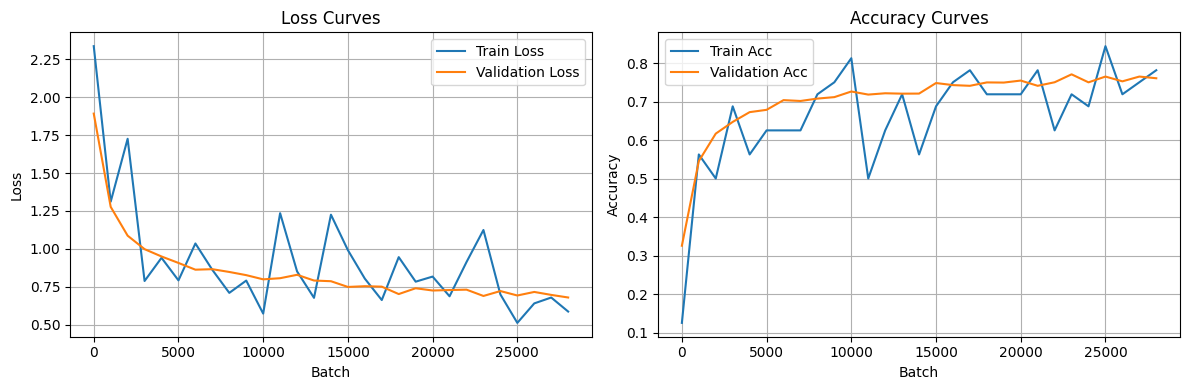

In [15]:
trainer.plot_curves()
